# Meshing

Implements the paper's Section 2.4.5, following on from
[point_cloud_registration.ipynb](point_cloud_registration.ipynb):

> Following the point-cloud registration and merging operations described above, the points
> require connecting to form a surface mesh before texturing can be applied. Poisson surface
> reconstruction was used for this stage and was chosen for its relative simplicity and
> reliability. Some care is needed to avoid loss of detail on inscribed surfaces. We found that
> an octree depth of 14 gave a good compromise, retaining the detail of the inscriptions with a
> tractable computational complexity.

Implemented via `open3d` (see `utils/meshing.py`), whose Poisson filter wraps Kazhdan's own
reference PoissonRecon implementation. The mesh this
notebook writes is a plain vertex-coloured PLY, which MeshLab reads natively, so Step 9 can still
use MeshLab even though this step no longer does.

**Pipeline in this notebook:**
1. Load Step 7's merged, registered point-cloud and per-point confidence.
2. **Remove isolated points** - not in the paper, added here after finding that Poisson
   reconstructs a small, completely disconnected "bubble" surface off in empty space on this
   replica's own merged cloud. The cause turned out to be a handful of near-isolated points
   (registration/fusion debris, not a real second surface) - Poisson fits one *global* implicit
   function, so even a few far-flung points, each with their own plausible local normal, can pull
   its zero-level-set out into a sizeable phantom surface. Removing them from the point cloud
   avoids the bubble at the source, rather than needing to run the reconstruction once just to
   find and trim it afterwards.
3. Estimate consistently-oriented per-point normals (Riemannian-graph propagation, not a
   single-viewpoint heuristic - the merged cloud combines several original viewpoints) - Poisson
   needs these; it can't work from raw positions alone.
4. **Screened Poisson surface reconstruction** at the paper's own `depth=14`.
5. Write the resulting mesh to `outputs/mesh/mesh.ply`, ready for Step 9 (Texturing).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from utils import meshing as mesh
from utils import registration as reg

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Parameters

In [2]:
ROOT = Path.cwd()
MERGED_PLY = ROOT / "outputs" / "merged" / "merged.ply"
MERGED_CONFIDENCE = ROOT / "outputs" / "merged" / "merged_confidence.npy"
OUT_DIR = ROOT / "outputs" / "mesh"
OUT_MESH_PLY = OUT_DIR / "mesh.ply"

# Isolated-point removal (not paper spec - see Step 2 below). Connects points within
# ISOLATION_RADIUS_MM of each other; drops any resulting group smaller than MIN_COMPONENT_SIZE.
ISOLATION_RADIUS_MM = 1.5
MIN_COMPONENT_SIZE = 10

# Normal estimation (PCA + Riemannian-graph consistent orientation).
NORMAL_K = 16

# Screened Poisson (paper spec: depth=14).
POISSON_DEPTH = 14
POISSON_SCALE = 1.1
POISSON_LINEAR_FIT = False

if OUT_DIR.exists():
    import shutil
    shutil.rmtree(OUT_DIR)
OUT_DIR.mkdir(parents=True)

## Step 1 - Load the merged point-cloud

In [3]:
points, colors = reg.read_ply(MERGED_PLY)
confidence = np.load(MERGED_CONFIDENCE)
print(f"{len(points):,} points, confidence mean={confidence.mean():.2f} "
      f"(min={confidence.min():.2f}, max={confidence.max():.2f})")

67,820 points, confidence mean=0.68 (min=0.00, max=1.00)


## Step 2 - Remove isolated points

See the notebook intro. Connects points within `ISOLATION_RADIUS_MM` of each other and drops any
resulting group smaller than `MIN_COMPONENT_SIZE` - on this replica's merged cloud, that's the
difference between one 67,805-point component and a scatter of 1-4-point fragments.

In [4]:
clean_points, clean_colors, clean_confidence = mesh.remove_isolated_points(
    points, colors, confidence, radius=ISOLATION_RADIUS_MM, min_component_size=MIN_COMPONENT_SIZE
)
print(f"removed {len(points) - len(clean_points):,} isolated points "
      f"({(len(points) - len(clean_points)) / len(points):.2%}) -> {len(clean_points):,} remain")
print("bounding box before:", points.min(axis=0), points.max(axis=0))
print("bounding box after: ", clean_points.min(axis=0), clean_points.max(axis=0))

removed 15 isolated points (0.02%) -> 67,805 remain
bounding box before: [-18.05402756 -56.95770264 -64.85522461] [53.32266235 66.87851715 46.12342834]
bounding box after:  [-16.98988724 -21.9190712   -1.80532897] [ 5.72650814 11.39112377 40.11363983]


## Step 3 - Estimate normals

Poisson reconstruction needs oriented surface normals, not just positions - the paper's own
dense-reconstruction stage would ordinarily supply these from photo-consistency, but Step 5's
`pycolmap`-based fusion doesn't preserve them (see Step 7's notebook), and in any case the merged
cloud here combines several original viewpoints with no single consistent "outward" direction to
assume.

In [5]:
pcd = mesh.build_point_cloud(clean_points, clean_colors)
mesh.estimate_normals(pcd, k=NORMAL_K)
print(f"estimated normals for {len(pcd.points):,} points")

estimated normals for 67,805 points


## Step 4 - Screened Poisson surface reconstruction

In [6]:
import time

t0 = time.time()
tri_mesh, densities = mesh.poisson_reconstruct(
    pcd, depth=POISSON_DEPTH, scale=POISSON_SCALE, linear_fit=POISSON_LINEAR_FIT
)
elapsed = time.time() - t0

mesh_vertices, mesh_faces, mesh_colors = mesh.mesh_arrays(tri_mesh)
print(f"Poisson reconstruction: {elapsed:.1f}s -> {len(mesh_vertices):,} vertices, {len(mesh_faces):,} faces")
print("mesh bounding box:", mesh_vertices.min(axis=0), mesh_vertices.max(axis=0))
print("Poisson density percentiles (0/5/50/95/100%):", np.percentile(densities, [0, 5, 50, 95, 100]))

Poisson reconstruction: 30.6s -> 196,419 vertices, 391,782 faces
mesh bounding box: [-16.99047661 -21.87025833  -0.405581  ] [ 5.6044426  11.33187294 40.73956299]
Poisson density percentiles (0/5/50/95/100%): [4.18555212 6.28869891 7.63900995 8.14516478 8.83827019]


## The mesh

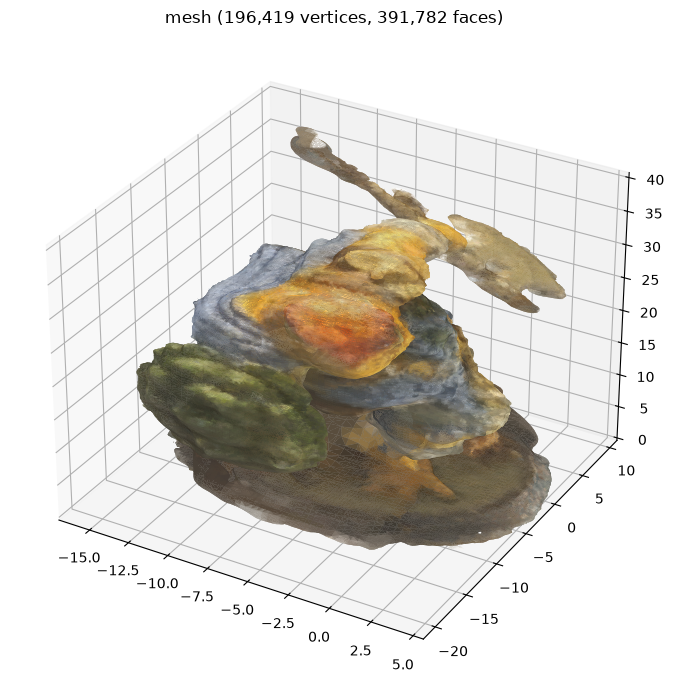

In [7]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")
tri_verts = mesh_vertices[mesh_faces]
face_colors = mesh_colors[mesh_faces].mean(axis=1) / 255.0 if mesh_colors is not None else "gray"
pc = Poly3DCollection(tri_verts, facecolor=face_colors, edgecolor="none")
ax.add_collection3d(pc)
ax.set_xlim(mesh_vertices[:, 0].min(), mesh_vertices[:, 0].max())
ax.set_ylim(mesh_vertices[:, 1].min(), mesh_vertices[:, 1].max())
ax.set_zlim(mesh_vertices[:, 2].min(), mesh_vertices[:, 2].max())
ax.set_title(f"mesh ({len(mesh_vertices):,} vertices, {len(mesh_faces):,} faces)")
plt.tight_layout()
plt.show()

## Write the mesh

In [8]:
mesh.write_mesh(OUT_MESH_PLY, tri_mesh)
print(f"wrote {OUT_MESH_PLY}")

[Open3D WARNING] Write Ply clamped color value to valid range
wrote /home/gnoceras/ScanningTable/outputs/mesh/mesh.ply


## Summary

In [9]:
print(f"input points:          {len(points):,}")
print(f"after isolation removal: {len(clean_points):,} ({len(points) - len(clean_points):,} removed)")
print(f"Poisson depth:          {POISSON_DEPTH}")
print(f"Poisson time:           {elapsed:.1f}s")
print(f"final mesh:             {len(mesh_vertices):,} vertices, {len(mesh_faces):,} faces")
print(f"wrote:                  {OUT_MESH_PLY}")

input points:          67,820
after isolation removal: 67,805 (15 removed)
Poisson depth:          14
Poisson time:           30.6s
final mesh:             196,419 vertices, 391,782 faces
wrote:                  /home/gnoceras/ScanningTable/outputs/mesh/mesh.ply
